# 01 — Exploratory Data Analysis
Characterises the IMDB reviews dataset for report section **3 — Dados utilizados**.

In [20]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

from src.utils import load_data

sns.set_theme(style='whitegrid')
SEED = 42

## 1. Load data

In [21]:
train_texts, train_labels = load_data('train')
test_texts,  test_labels  = load_data('test')

train_df = pd.DataFrame({'text': train_texts, 'label': train_labels})
test_df  = pd.DataFrame({'text': test_texts,  'label': test_labels})

print(f'Train: {len(train_df):,} rows')
print(f'Test : {len(test_df):,} rows')

Train: 41,750 rows
Test : 2,000 rows


## 2. Class distribution

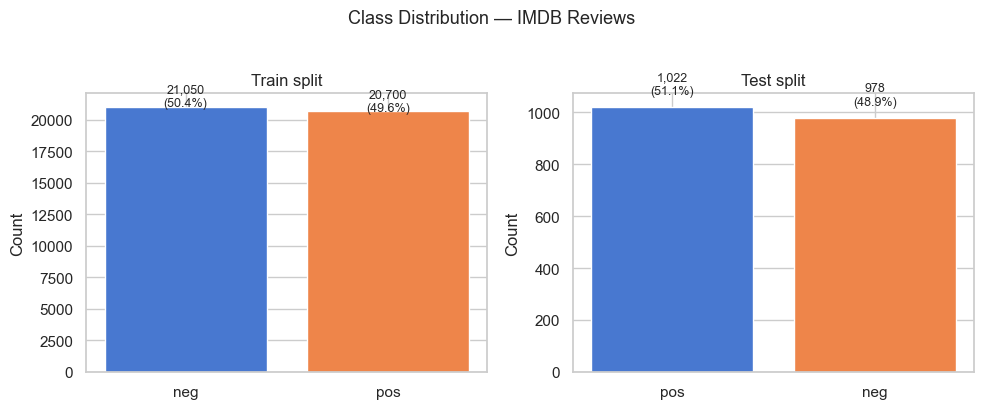

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, df, title in zip(axes, [train_df, test_df], ['Train', 'Test']):
    counts = df['label'].value_counts()
    ax.bar(counts.index, counts.values, color=['#4878D0', '#EE854A'])
    ax.set_title(f'{title} split')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)
plt.suptitle('Class Distribution — IMDB Reviews', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/fig_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Token count distribution

In [23]:
train_df['n_tokens'] = train_df['text'].apply(lambda x: len(x.split()))
test_df['n_tokens']  = test_df['text'].apply(lambda x: len(x.split()))

print('=== Train ===')
print(train_df.groupby('label')['n_tokens'].describe().round(1))
print('\n=== Test ===')
print(test_df.groupby('label')['n_tokens'].describe().round(1))

=== Train ===
         count   mean   std   min    25%    50%    75%    max
label                                                        
neg    21050.0  180.4  83.5   4.0  124.0  160.0  228.0  463.0
pos    20700.0  176.5  84.9  10.0  119.0  156.0  225.0  466.0

=== Test ===
        count   mean   std   min    25%    50%    75%    max
label                                                       
neg     978.0  177.2  82.3   9.0  122.0  157.0  226.0  422.0
pos    1022.0  173.6  84.3  24.0  119.0  152.0  219.0  426.0


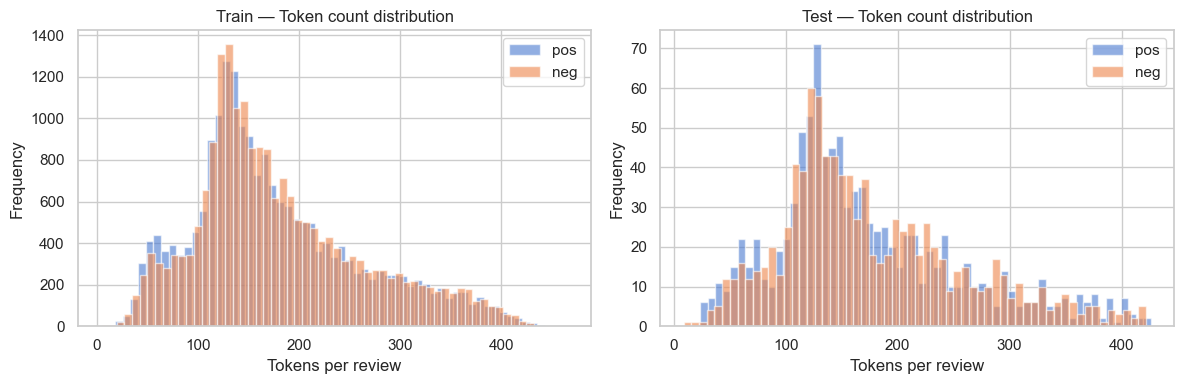

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in zip(axes, [train_df, test_df], ['Train', 'Test']):
    for label, color in [('pos', '#4878D0'), ('neg', '#EE854A')]:
        subset = df[df['label'] == label]['n_tokens']
        ax.hist(subset, bins=60, alpha=0.6, label=label, color=color)
    ax.set_title(f'{title} — Token count distribution')
    ax.set_xlabel('Tokens per review')
    ax.set_ylabel('Frequency')
    ax.legend()
plt.tight_layout()
plt.savefig('../results/fig_token_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Most frequent words

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>


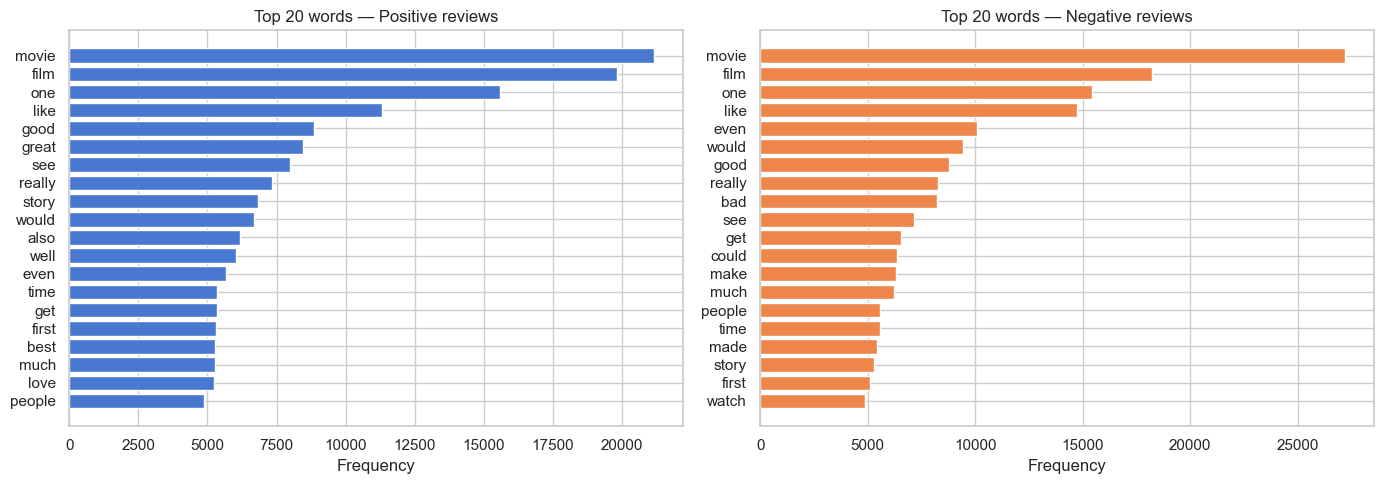

In [25]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
stop = set(stopwords.words('english'))

def top_words(texts, n=20):
    words = []
    for t in texts:
        words.extend([w.lower() for w in t.split() if w.lower() not in stop and w.isalpha()])
    return Counter(words).most_common(n)

pos_texts = train_df[train_df['label'] == 'pos']['text'].tolist()
neg_texts = train_df[train_df['label'] == 'neg']['text'].tolist()

pos_top = top_words(pos_texts)
neg_top = top_words(neg_texts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, top, title, color in zip(axes, [pos_top, neg_top], ['Positive', 'Negative'], ['#4878D0', '#EE854A']):
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(f'Top 20 words — {title} reviews')
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('../results/fig_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Word clouds

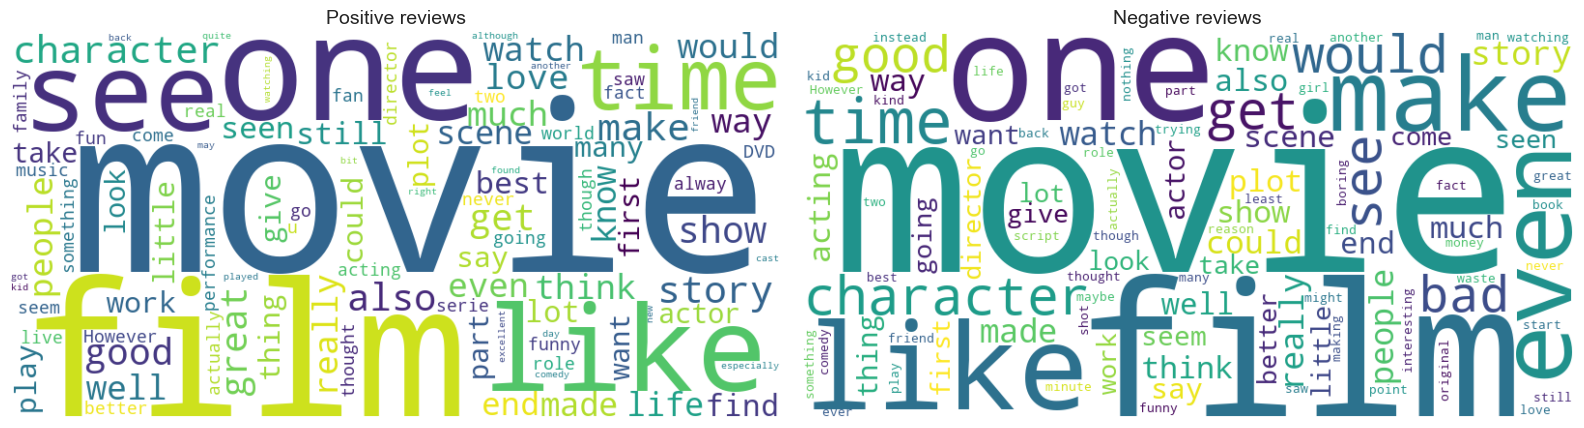

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, texts, title in zip(axes, [pos_texts, neg_texts], ['Positive', 'Negative']):
    corpus = ' '.join(texts)
    wc = WordCloud(width=800, height=400, background_color='white',
                   stopwords=stop, max_words=100).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{title} reviews', fontsize=14)
plt.tight_layout()
plt.savefig('../results/fig_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Sample reviews

In [29]:
import random
random.seed(SEED)

for label in ['pos', 'neg']:
    sample = random.choice(train_df[train_df['label'] == label]['text'].tolist())
    print(f'[{label.upper()}] {sample[:400]}...\n')

[POS] The movie itself made me want to go and call someone so they could enjoy it too. It was extremely funny. Angelena Jolie was wonderful as Juliet. The parents are hilarious.They are caterers as well as enemies.The kids play the parts of Romeo and Juliet in the church play.They fall in love and their parents try to keep them apart.(Spoiler Ahead. I think) They sneak off after a party and do it. Surpr...

[NEG] In the 3rd installment of "Left Behind" the makers did not care to put ANY KIND OF CONTINUITY into the plot. Although all weapons on the planet have been confiscated by the United Nations, World War III suddenly begins at the snap of a finger. Within a few split seconds the ex lover of one of the main protagonists moves from passionately seducing him to outright hatred to a melancholy confession o...



## 7. Dataset summary table

In [30]:
summary = pd.DataFrame([
    {
        'Split': 'Train',
        'Total': len(train_df),
        'Positive': (train_df['label']=='pos').sum(),
        'Negative': (train_df['label']=='neg').sum(),
        'Avg tokens': round(train_df['n_tokens'].mean(), 1),
        'Max tokens': train_df['n_tokens'].max(),
    },
    {
        'Split': 'Test',
        'Total': len(test_df),
        'Positive': (test_df['label']=='pos').sum(),
        'Negative': (test_df['label']=='neg').sum(),
        'Avg tokens': round(test_df['n_tokens'].mean(), 1),
        'Max tokens': test_df['n_tokens'].max(),
    },
])
display(summary)

,Split,Total,Positive,Negative,Avg tokens,Max tokens
0,Train,41750,20700,21050,178.4,466
1,Test,2000,1022,978,175.3,426
